# Home Credit Binary Classification with Backward Selection, To integrate with final project 

This notebook uses the original exhaustive backward-selection approach with balanced logistic regression and cross-validated ROC AUC.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, classification_report, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

random_seed = 42

In [15]:
DATA_DIR = Path("DATA/home-credit-default-risk")
Home_Credit_app_TRAIN = pd.read_csv(DATA_DIR / "application_train.csv")

# Keep numeric and categorical raw features. Encoding and imputation happen inside each CV fold.
X = Home_Credit_app_TRAIN.drop(columns="TARGET")
X = X.dropna(axis=1, how="all")
y = Home_Credit_app_TRAIN["TARGET"]

# Keep this test set untouched until final evaluation.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=random_seed,
    stratify=y,
)

# Use a smaller stratified sample for the expensive backward-selection search.
X_selection, _, y_selection, _ = train_test_split(
    X_train_full,
    y_train_full,
    train_size=15_000,
    random_state=random_seed,
    stratify=y_train_full,
)

print(f"Starting raw features: {X.shape[1]}")
print(f"Numeric features: {len(X.select_dtypes(include=np.number).columns)}")
print(f"Categorical features: {len(X.select_dtypes(exclude=np.number).columns)}")
print(f"Feature-selection rows: {len(X_selection):,}")
print(f"Positive-class rate: {y.mean():.3%}")

Starting raw features: 121
Numeric features: 105
Categorical features: 16
Feature-selection rows: 15,000
Positive-class rate: 8.073%


In [16]:
def make_logistic_model(feature_frame):
    numeric_columns = feature_frame.select_dtypes(include=np.number).columns.tolist()
    categorical_columns = feature_frame.select_dtypes(exclude=np.number).columns.tolist()

    transformers = []
    if numeric_columns:
        transformers.append((
            "numeric",
            make_pipeline(SimpleImputer(strategy="median"), StandardScaler()),
            numeric_columns,
        ))
    if categorical_columns:
        transformers.append((
            "categorical",
            make_pipeline(
                SimpleImputer(strategy="most_frequent"),
                OneHotEncoder(handle_unknown="ignore"),
            ),
            categorical_columns,
        ))

    return Pipeline([
        ("preprocessor", ColumnTransformer(transformers=transformers)),
        ("classifier", LogisticRegression(class_weight="balanced", max_iter=1_000)),
    ])


def backward_feature_selection(
    X,
    y,
    cv=3,
    scoring="roc_auc",
    min_improvement=0.0005,
    min_features=1,
    verbose=True,
):
    """Remove a feature only when its removal meaningfully improves CV performance."""
    if isinstance(cv, int):
        cv = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_seed)

    selected_features = list(X.columns)
    current_score = cross_val_score(
        make_logistic_model(X[selected_features]),
        X[selected_features], y, cv=cv, scoring=scoring, n_jobs=-1
    ).mean()
    history = [{
        "step": 0,
        "removed_feature": None,
        "num_features": len(selected_features),
        "cv_score": current_score,
    }]

    if verbose:
        print(f"Starting {scoring}: {current_score:.6f}")

    step = 1
    while len(selected_features) > min_features:
        trial_results = []
        for feature in selected_features:
            trial_features = [column for column in selected_features if column != feature]
            trial_score = cross_val_score(
                make_logistic_model(X[trial_features]),
                X[trial_features], y, cv=cv, scoring=scoring, n_jobs=-1
            ).mean()
            trial_results.append({"feature_removed": feature, "cv_score": trial_score})

        results = pd.DataFrame(trial_results)
        best_row = results.loc[results["cv_score"].idxmax()]
        best_feature = best_row["feature_removed"]
        best_score = best_row["cv_score"]
        improvement = best_score - current_score

        if verbose:
            print(
                f"Step {step}: try removing {best_feature!r} -> "
                f"{scoring}: {best_score:.6f}, improvement: {improvement:+.6f}"
            )

        if improvement < min_improvement:
            if verbose:
                print(
                    f"Stopping: no removal improves {scoring} by at least "
                    f"{min_improvement:.6f}."
                )
            break

        selected_features.remove(best_feature)
        current_score = best_score
        history.append({
            "step": step,
            "removed_feature": best_feature,
            "num_features": len(selected_features),
            "cv_score": current_score,
        })
        step += 1

    return selected_features, pd.DataFrame(history)

In [17]:
selected_features, selection_history = backward_feature_selection(
    X_selection,
    y_selection,
    cv=3,
    scoring="roc_auc",
    min_improvement=0.0005,
)

removed_features = selection_history["removed_feature"].dropna().tolist()
print(f"\nRemoved {len(removed_features)} features: {removed_features}")
print(f"Retained {len(selected_features)} features.")
display(selection_history)

Starting roc_auc: 0.703192
Step 1: try removing 'ORGANIZATION_TYPE' -> roc_auc: 0.711327, improvement: +0.008135
Step 2: try removing 'HOUSETYPE_MODE' -> roc_auc: 0.713501, improvement: +0.002174
Step 3: try removing 'OCCUPATION_TYPE' -> roc_auc: 0.715649, improvement: +0.002147
Step 4: try removing 'LIVINGAREA_MODE' -> roc_auc: 0.717042, improvement: +0.001393
Step 5: try removing 'YEARS_BEGINEXPLUATATION_MEDI' -> roc_auc: 0.718298, improvement: +0.001257
Step 6: try removing 'FONDKAPREMONT_MODE' -> roc_auc: 0.719415, improvement: +0.001117
Step 7: try removing 'FLAG_EMAIL' -> roc_auc: 0.720308, improvement: +0.000893
Step 8: try removing 'FLAG_DOCUMENT_8' -> roc_auc: 0.721274, improvement: +0.000966
Step 9: try removing 'FLAG_DOCUMENT_21' -> roc_auc: 0.722071, improvement: +0.000797
Step 10: try removing 'FLAG_DOCUMENT_19' -> roc_auc: 0.722879, improvement: +0.000808
Step 11: try removing 'NAME_TYPE_SUITE' -> roc_auc: 0.723490, improvement: +0.000612
Step 12: try removing 'YEARS_BUIL

,step,removed_feature,num_features,cv_score
0,0,NaN,121,0.703192
1,1,ORGANIZATION_TYPE,120,0.711327
2,2,HOUSETYPE_MODE,119,0.713501
3,3,OCCUPATION_TYPE,118,0.715649
4,4,LIVINGAREA_MODE,117,0.717042
5,5,YEARS_BEGINEXPLUATATION_MEDI,116,0.718298
6,6,FONDKAPREMONT_MODE,115,0.719415
7,7,FLAG_EMAIL,114,0.720308
8,8,FLAG_DOCUMENT_8,113,0.721274
9,9,FLAG_DOCUMENT_21,112,0.722071


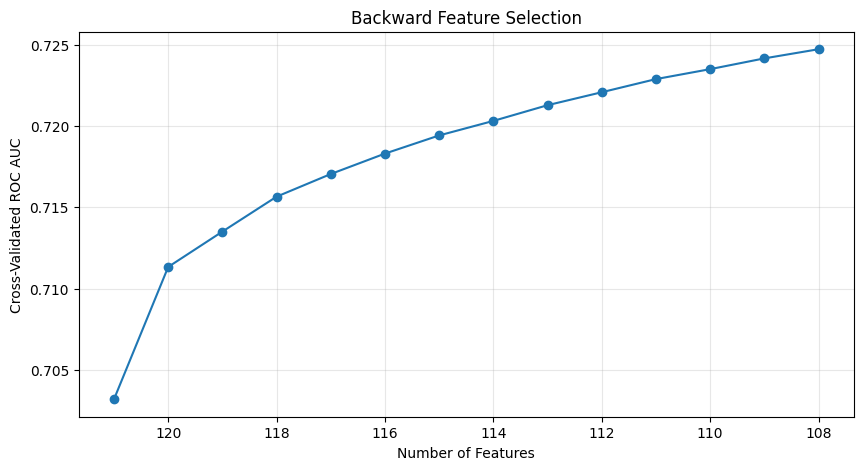

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(selection_history["num_features"], selection_history["cv_score"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel("Number of Features")
plt.ylabel("Cross-Validated ROC AUC")
plt.title("Backward Feature Selection")
plt.grid(alpha=0.3)
plt.show()

In [21]:
# Train the final selected-feature model on all training rows.
final_model = make_logistic_model(X_train_full[selected_features])
final_model.fit(X_train_full[selected_features], y_train_full)

test_probability = final_model.predict_proba(X_test[selected_features])[:, 1]
test_prediction = final_model.predict(X_test[selected_features])

print(f"Test ROC AUC: {roc_auc_score(y_test, test_probability):.3f}")
print(f"Test average precision: {average_precision_score(y_test, test_probability):.3f}")
print(f"Positive-class baseline: {y_test.mean():.3f}")
print(classification_report(y_test, test_prediction, digits=3))

Test ROC AUC: 0.747
Test average precision: 0.228
Positive-class baseline: 0.081
              precision    recall  f1-score   support

           0      0.960     0.690     0.803     56538
           1      0.161     0.677     0.260      4965

    accuracy                          0.689     61503
   macro avg      0.561     0.683     0.532     61503
weighted avg      0.896     0.689     0.759     61503

